# OULAD literature replication: Withdrawn versus Others

This notebook keeps the capstone problem statement fixed throughout:

- **Positive class (`1`)**: `final_result == "Withdrawn"`
- **Negative class (`0`)**: `Pass`, `Fail`, or `Distinction`
- **Primary operational comparison**: information available by 25% of each course presentation
- **Frozen reference from `checkpoint1_EDA_v3.ipynb`**: PR-AUC `0.825`, ROC-AUC `0.884`

The notebook reconstructs the 50 predictors used by Jha, Ghergulescu, and Moldovan (2019): eight student-profile attributes, two non-exam assessment averages, and click/visit aggregates for each of the twenty VLE activity types. It runs that implementation twice:

1. **Whole-course reconstruction**, to investigate the paper's reported ROC-AUC of about 0.90-0.91.
2. **Fair early-warning comparison**, where the same features are rebuilt using only evidence available by the 25% checkpoint and evaluated on the student-grouped split used in the current baseline.

Whole-course and early-warning results are deliberately reported separately. A whole-course score is not evidence of improved early-warning performance.

## Literature evidence and target audit

| Eligibility | Source | Target and reported result | Comparability finding |
|---|---|---|---|
| Same target; primary reconstruction | [Jha et al. (2019), *OULAD MOOC Dropout and Result Prediction*](https://pdfs.semanticscholar.org/4d82/e06071af59bf3d74068c89f49024faa24848.pdf) | Binary dropout yes/no; approximately 0.90-0.91 ROC-AUC using VLE, assessment, and demographic aggregates | Same label, but uses whole-course aggregates and a row-level holdout |
| Same target; rigorous early benchmark | [Wu et al. (2026), PLOS ONE](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0352867) | `Withdrawn = 1`, all other results `= 0`; ROC-AUC 0.794 and PR-AUC 0.664 at 28 days under course-presentation holdout | Stronger leakage and generalization controls than most headline studies |
| Different target | [Almazroei et al. (2026), Scientific Reports](https://www.nature.com/articles/s41598-026-49894-1) | `Fail + Withdrawn = at-risk`; `Pass + Distinction = successful`; XGBoost ROC-AUC 0.98834, F1 0.95244, accuracy 0.95398 | Not the capstone target; the paper also reports `date_unregistration` and cumulative assessment measures among top predictors |
| Different-target implementation | [Published code for Almazroei et al.](https://github.com/EssaAlmazroei/Test/blob/master/Code.ipynb) | Python preprocessing and modelling notebook linked by the paper | Useful for explaining the high score, not for replacing the withdrawal model |
| Different target | [Abdo et al. (2025), stacking ensemble](https://oaji.net/pdf.html?n=2023%2F3603-1760663243.pdf) | `Pass + Distinction` versus `Fail + Withdrawn`; test ROC-AUC 0.973748, F1 0.940220, accuracy 0.927297 | Uses whole-course features and removes 6,807 learners without assessment and VLE evidence |
| Target inferred, not explicit in accessible text | [Azuela et al. (2025), IEEE ETECOM](https://www.researchgate.net/publication/399705152_From_Data_to_Action_Narrative_Benchmarking_and_Comparative_Evaluation_of_Explainable_AI-Driven_Supervised_Machine_Learning_Models_for_Academic_Risk_Prediction) | XGBoost ROC-AUC 0.974233 and F1 0.916981; reported class supports match the OULAD `Fail + Withdrawn` versus `Pass + Distinction` grouping | Retained as a high-score lead with an explicit target-verification warning |
| Ineligible 0.97 claim | [Al-Shabandar et al. (2018), Gaussian mixtures](https://researchonline.ljmu.ac.uk/8486/1/New%20update%20paper%20mixture%20model%20PDF%20%20%20last%20Dr%20Abir.pdf) | AUC as high as about 0.97 | Course BBB only; interval label is whether the next assignment was submitted, not `final_result == Withdrawn` |

The high numbers are real reported values, but they do not all measure the same prediction problem. This notebook implements only the same-target method.

In [1]:
from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
KEYS = ["id_student", "code_module", "code_presentation"]
PROFILE_FEATURES = [
    "gender", "region", "highest_education", "imd_band", "age_band",
    "disability", "num_of_prev_attempts", "studied_credits",
]
BASELINE_REFERENCE = {
    "model": "checkpoint1_EDA_v3: HGB, withdrawal weight 3.0",
    "pr_auc": 0.8248301223758441,
    "roc_auc": 0.8841793059527716,
    "balanced_accuracy": 0.8191925703658556,
    "precision": 0.6929971988795518,
    "recall": 0.8032467532467532,
    "f1": 0.7440601503759399,
    "fp": 548,
    "fn": 303,
}
print("Environment ready. Frozen baseline:")
display(pd.DataFrame([BASELINE_REFERENCE]))

Environment ready. Frozen baseline:


,model,pr_auc,roc_auc,balanced_accuracy,precision,recall,f1,fp,fn
0,"checkpoint1_EDA_v3: HGB, withdrawal weight 3.0",0.82483,0.884179,0.819193,0.692997,0.803247,0.74406,548,303


In [2]:
def locate_oulad_directory(start: Path) -> Path:
    candidates = []
    for parent in [start.resolve(), *start.resolve().parents]:
        candidates.extend([
            parent / "open+university+learning+analytics+dataset",
            parent / "oulad",
            parent / "data" / "oulad",
        ])
    for candidate in candidates:
        if (candidate / "studentInfo.csv").exists() and (candidate / "studentVle.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate the raw OULAD CSV directory from the notebook working directory.")


DATA_DIR = locate_oulad_directory(Path.cwd())
print("OULAD directory:", DATA_DIR)

courses = pd.read_csv(DATA_DIR / "courses.csv")
assessments = pd.read_csv(DATA_DIR / "assessments.csv")
student_info = pd.read_csv(DATA_DIR / "studentInfo.csv")
student_assessment = pd.read_csv(DATA_DIR / "studentAssessment.csv")
vle = pd.read_csv(DATA_DIR / "vle.csv")
student_vle = pd.read_csv(
    DATA_DIR / "studentVle.csv",
    dtype={
        "code_module": "category",
        "code_presentation": "category",
        "id_student": "int32",
        "id_site": "int32",
        "date": "int16",
        "sum_click": "int32",
    },
)

print("Loaded shapes:")
display(pd.DataFrame({
    "table": ["courses", "assessments", "studentInfo", "studentAssessment", "vle", "studentVle"],
    "rows": [len(courses), len(assessments), len(student_info), len(student_assessment), len(vle), len(student_vle)],
}))

OULAD directory: C:\Users\creak\Downloads\eMasters Capstone Project\open+university+learning+analytics+dataset


Loaded shapes:


,table,rows
0,courses,22
1,assessments,206
2,studentInfo,32593
3,studentAssessment,173912
4,vle,6364
5,studentVle,10655280


## Target and feature construction

The Jha feature layout contains exactly 50 raw predictors:

- 8 student-profile predictors;
- 2 mean non-exam assessment scores (`TMA`, `CMA`);
- 20 total-click predictors, one per VLE activity type;
- 20 visit/event-count predictors, one per VLE activity type.

For the early version, assessment submissions and VLE interactions are filtered **before aggregation**. This prevents later evidence from contaminating an apparently early feature.

In [3]:
student_info = student_info.copy()
student_info["target_withdrawn"] = (student_info["final_result"] == "Withdrawn").astype("int8")

target_audit = pd.crosstab(student_info["final_result"], student_info["target_withdrawn"])
display(target_audit)
assert student_info.loc[student_info["final_result"] == "Withdrawn", "target_withdrawn"].eq(1).all()
assert student_info.loc[student_info["final_result"] != "Withdrawn", "target_withdrawn"].eq(0).all()
assert student_info.duplicated(KEYS).sum() == 0

activity_types = sorted(vle["activity_type"].dropna().unique().tolist())
print("VLE activity types:", len(activity_types), activity_types)
assert len(activity_types) == 20, "Jha et al. describe 20 VLE activity types."

checkpoint_table = courses[["code_module", "code_presentation", "module_presentation_length"]].copy()
checkpoint_table["checkpoint_day"] = (
    checkpoint_table["module_presentation_length"] * 0.25
).round().astype(int)

target_withdrawn,0,1
final_result,,
Distinction,3024,0
Fail,7052,0
Pass,12361,0
Withdrawn,0,10156


VLE activity types: 20 ['dataplus', 'dualpane', 'externalquiz', 'folder', 'forumng', 'glossary', 'homepage', 'htmlactivity', 'oucollaborate', 'oucontent', 'ouelluminate', 'ouwiki', 'page', 'questionnaire', 'quiz', 'repeatactivity', 'resource', 'sharedsubpage', 'subpage', 'url']


In [4]:
def build_jha_features(window_fraction=None):
    # Build Jha-style 50 predictors using all data or a strict course-relative cutoff.
    base = student_info[KEYS + PROFILE_FEATURES + ["target_withdrawn"]].copy()

    assessment_events = student_assessment.merge(
        assessments,
        on="id_assessment",
        how="left",
        validate="many_to_one",
    )
    assessment_events = assessment_events[
        assessment_events["assessment_type"].isin(["TMA", "CMA"])
    ].copy()
    # The source CSV can be inferred as object in some pandas versions because
    # missing marks are encoded textually. Coerce before taking grouped means.
    assessment_events["score"] = pd.to_numeric(assessment_events["score"], errors="coerce")
    assessment_events["date_submitted"] = pd.to_numeric(
        assessment_events["date_submitted"], errors="coerce"
    )

    vle_events = student_vle.merge(
        vle[["id_site", "code_module", "code_presentation", "activity_type"]],
        on=["id_site", "code_module", "code_presentation"],
        how="left",
        validate="many_to_one",
    )

    audit = {"window": "whole_course" if window_fraction is None else f"{window_fraction:.0%}"}
    if window_fraction is not None:
        cutoffs = courses[["code_module", "code_presentation", "module_presentation_length"]].copy()
        cutoffs["checkpoint_day"] = (
            cutoffs["module_presentation_length"] * window_fraction
        ).round().astype(int)

        assessment_events = assessment_events.merge(
            cutoffs[["code_module", "code_presentation", "checkpoint_day"]],
            on=["code_module", "code_presentation"],
            how="left",
            validate="many_to_one",
        )
        assessment_events = assessment_events[
            assessment_events["date_submitted"].notna()
            & (assessment_events["date_submitted"] <= assessment_events["checkpoint_day"])
        ].copy()

        vle_events = vle_events.merge(
            cutoffs[["code_module", "code_presentation", "checkpoint_day"]],
            on=["code_module", "code_presentation"],
            how="left",
            validate="many_to_one",
        )
        vle_events = vle_events[vle_events["date"] <= vle_events["checkpoint_day"]].copy()

        audit["max_assessment_days_past_cutoff"] = int(
            (assessment_events["date_submitted"] - assessment_events["checkpoint_day"]).max()
        ) if len(assessment_events) else 0
        audit["max_vle_days_past_cutoff"] = int(
            (vle_events["date"] - vle_events["checkpoint_day"]).max()
        ) if len(vle_events) else 0
        assert audit["max_assessment_days_past_cutoff"] <= 0
        assert audit["max_vle_days_past_cutoff"] <= 0

    assessment_means = (
        assessment_events.groupby(KEYS + ["assessment_type"], observed=True)["score"]
        .mean()
        .unstack("assessment_type")
        .reindex(columns=["TMA", "CMA"])
        .rename(columns={"TMA": "avg_TMA_score", "CMA": "avg_CMA_score"})
        .reset_index()
    )

    click_features = (
        vle_events.groupby(KEYS + ["activity_type"], observed=True)["sum_click"]
        .sum()
        .unstack("activity_type", fill_value=0)
        .reindex(columns=activity_types, fill_value=0)
    )
    click_features.columns = [f"sum_clicks_{name}" for name in click_features.columns]

    visit_features = (
        vle_events.groupby(KEYS + ["activity_type"], observed=True)
        .size()
        .unstack("activity_type", fill_value=0)
        .reindex(columns=activity_types, fill_value=0)
    )
    visit_features.columns = [f"count_visits_{name}" for name in visit_features.columns]

    vle_features = click_features.join(visit_features, how="outer").reset_index()
    result = base.merge(assessment_means, on=KEYS, how="left", validate="one_to_one")
    result = result.merge(vle_features, on=KEYS, how="left", validate="one_to_one")

    vle_columns = [c for c in result.columns if c.startswith("sum_clicks_") or c.startswith("count_visits_")]
    result[vle_columns] = result[vle_columns].fillna(0)
    feature_columns = PROFILE_FEATURES + ["avg_TMA_score", "avg_CMA_score"] + vle_columns

    assert len(result) == len(student_info)
    assert result.duplicated(KEYS).sum() == 0
    assert len(feature_columns) == 50, f"Expected 50 Jha predictors, got {len(feature_columns)}"
    assert "date_unregistration" not in result.columns
    assert "final_result" not in feature_columns

    audit.update({
        "rows": len(result),
        "withdrawn": int(result["target_withdrawn"].sum()),
        "assessment_records_used": len(assessment_events),
        "vle_records_used": len(vle_events),
        "raw_predictors": len(feature_columns),
    })
    return result, feature_columns, audit


started = time.time()
full_features, full_feature_columns, full_audit = build_jha_features(window_fraction=None)
early_features, early_feature_columns, early_audit = build_jha_features(window_fraction=0.25)
print(f"Feature construction completed in {time.time() - started:.1f} seconds")
display(pd.DataFrame([full_audit, early_audit]))

Feature construction completed in 31.2 seconds


,window,rows,withdrawn,assessment_records_used,vle_records_used,raw_predictors,max_assessment_days_past_cutoff,max_vle_days_past_cutoff
0,whole_course,32593,10156,168953,10655280,50,NaN,NaN
1,25%,32593,10156,57013,4667957,50,0.0,0.0


In [5]:
feature_availability = pd.DataFrame({
    "feature": full_feature_columns,
    "family": [
        "Student profile" if c in PROFILE_FEATURES
        else "Assessment" if c.startswith("avg_")
        else "VLE clicks" if c.startswith("sum_clicks_")
        else "VLE visits"
        for c in full_feature_columns
    ],
    "whole_course_non_missing": [full_features[c].notna().mean() for c in full_feature_columns],
    "checkpoint_non_missing": [early_features[c].notna().mean() for c in early_feature_columns],
})
display(feature_availability.groupby("family").agg(
    features=("feature", "count"),
    whole_course_non_missing=("whole_course_non_missing", "mean"),
    checkpoint_non_missing=("checkpoint_non_missing", "mean"),
))

,features,whole_course_non_missing,checkpoint_non_missing
family,,,
Assessment,2,0.611911,0.545639
Student profile,8,1.000000,1.000000
VLE clicks,20,1.000000,1.000000
VLE visits,20,1.000000,1.000000


## Shared modelling utilities

All preprocessing is fitted inside a model pipeline. Categorical values are imputed and one-hot encoded; numerical values are median-imputed. Scale-sensitive logistic regression additionally standardizes numeric inputs. Tree models receive the unscaled numeric values.

In [6]:
def make_preprocessor(frame, feature_columns, scale_numeric=False):
    categorical = [c for c in feature_columns if frame[c].dtype == "object" or str(frame[c].dtype).startswith("category")]
    numeric = [c for c in feature_columns if c not in categorical]
    try:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))
    return ColumnTransformer([
        ("num", Pipeline(numeric_steps), numeric),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", encoder),
        ]), categorical),
    ]), numeric, categorical


def make_model(name, frame, feature_columns, xgb_params=None):
    scale = name == "LogisticRegression"
    preprocessor, _, _ = make_preprocessor(frame, feature_columns, scale_numeric=scale)
    if name == "LogisticRegression":
        estimator = LogisticRegression(
            max_iter=2000, class_weight="balanced", solver="lbfgs", random_state=RANDOM_STATE
        )
    elif name == "RandomForest":
        estimator = RandomForestClassifier(
            n_estimators=300, max_depth=None, min_samples_leaf=2,
            class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1,
        )
    elif name == "HistGradientBoosting":
        estimator = HistGradientBoostingClassifier(
            loss="log_loss", learning_rate=0.08, max_iter=200,
            max_leaf_nodes=31, random_state=RANDOM_STATE,
        )
    elif name == "XGBoost":
        params = {
            "n_estimators": 300, "max_depth": 4, "learning_rate": 0.05,
            "subsample": 0.85, "colsample_bytree": 0.85, "reg_lambda": 1.0,
        }
        if xgb_params:
            params.update(xgb_params)
        estimator = XGBClassifier(
            objective="binary:logistic", eval_metric="logloss", tree_method="hist",
            random_state=RANDOM_STATE, n_jobs=-1, **params,
        )
    else:
        raise ValueError(name)
    return Pipeline([("preprocess", preprocessor), ("model", estimator)])


def fit_pipeline(pipe, model_name, X, y, relative_positive_weight=None):
    fit_kwargs = {}
    if model_name in {"HistGradientBoosting", "XGBoost"}:
        if relative_positive_weight is None:
            weights = compute_sample_weight(class_weight="balanced", y=y)
        else:
            weights = np.where(y.to_numpy() == 1, relative_positive_weight, 1.0).astype(float)
            weights /= weights.mean()
        fit_kwargs["model__sample_weight"] = weights
    return pipe.fit(X, y, **fit_kwargs)


def metric_row(label, y_true, probability, threshold=0.5):
    prediction = (np.asarray(probability) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {
        "model": label,
        "accuracy": accuracy_score(y_true, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probability),
        "pr_auc": average_precision_score(y_true, probability),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


def formatted(frame):
    formats = {c: "{:.3f}" for c in [
        "accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"
    ] if c in frame.columns}
    return frame.style.format(formats)

## Experiment 1: whole-course paper reconstruction

This experiment deliberately follows the easier, retrospective setup: all VLE and non-exam assessment evidence is aggregated and rows are split randomly. Its purpose is to determine whether the literature feature design can reproduce the published performance range. It must not be compared directly with an intervention at 25% of the course.

In [7]:
X_full = full_features[full_feature_columns].copy()
y_full = full_features["target_withdrawn"].copy()

X_full_train, X_full_test, y_full_train, y_full_test = train_test_split(
    X_full, y_full, test_size=0.25, random_state=RANDOM_STATE, stratify=y_full
)

full_models = {}
full_probabilities = {}
full_rows = []
for model_name in ["LogisticRegression", "RandomForest", "HistGradientBoosting", "XGBoost"]:
    model = make_model(model_name, X_full_train, full_feature_columns)
    fit_pipeline(model, model_name, X_full_train, y_full_train)
    probability = model.predict_proba(X_full_test)[:, 1]
    full_models[model_name] = model
    full_probabilities[model_name] = probability
    full_rows.append(metric_row(model_name, y_full_test, probability))

full_results = pd.DataFrame(full_rows).sort_values(["roc_auc", "pr_auc"], ascending=False).reset_index(drop=True)
print("Whole-course reconstruction results:")
display(formatted(full_results))

C:\Users\creak\Anaconda3\envs\MLDL\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\creak\Anaconda3\envs\MLDL\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Whole-course reconstruction results:


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,HistGradientBoosting,0.830,0.845,0.674,0.883,0.764,0.922,0.838,4523,1087,296,2243
1,XGBoost,0.835,0.847,0.682,0.880,0.768,0.922,0.838,4567,1043,305,2234
2,RandomForest,0.842,0.818,0.741,0.755,0.748,0.919,0.829,4941,669,621,1918
3,LogisticRegression,0.807,0.825,0.640,0.873,0.739,0.896,0.764,4363,1247,322,2217


In [8]:
# Ten-fold diagnostic for the best whole-course model, matching the paper's CV convention.
best_full_name = full_results.iloc[0]["model"]
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
full_cv_rows = []
for fold, (train_idx, valid_idx) in enumerate(cv.split(X_full, y_full), start=1):
    fold_model = make_model(best_full_name, X_full.iloc[train_idx], full_feature_columns)
    fit_pipeline(fold_model, best_full_name, X_full.iloc[train_idx], y_full.iloc[train_idx])
    fold_probability = fold_model.predict_proba(X_full.iloc[valid_idx])[:, 1]
    fold_row = metric_row(f"fold_{fold}", y_full.iloc[valid_idx], fold_probability)
    full_cv_rows.append(fold_row)

full_cv_results = pd.DataFrame(full_cv_rows)
full_cv_summary = pd.DataFrame([{
    "model": best_full_name,
    "folds": 10,
    "roc_auc_mean": full_cv_results["roc_auc"].mean(),
    "roc_auc_std": full_cv_results["roc_auc"].std(),
    "pr_auc_mean": full_cv_results["pr_auc"].mean(),
    "pr_auc_std": full_cv_results["pr_auc"].std(),
}])
display(full_cv_summary.style.format({
    "roc_auc_mean": "{:.3f}", "roc_auc_std": "{:.3f}",
    "pr_auc_mean": "{:.3f}", "pr_auc_std": "{:.3f}",
}))

,model,folds,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,HistGradientBoosting,10,0.921,0.004,0.835,0.013


## Experiment 2: fair 25%-checkpoint comparison

The partition construction below mirrors `checkpoint1_EDA_v3.ipynb`: twenty student-grouped, approximately stratified folds are assigned once; fourteen folds form training, three evaluation, and three test. The same student cannot occur in more than one partition. The test partition remains unused in this exploratory literature comparison so the results align with the evaluation table supplied by the team.

In [9]:
X_early = early_features[early_feature_columns].copy()
y_early = early_features["target_withdrawn"].copy()
student_groups = early_features["id_student"].copy()

splitter = StratifiedGroupKFold(n_splits=20, shuffle=True, random_state=RANDOM_STATE)
fold_assignment = np.full(len(X_early), -1, dtype=int)
for fold_number, (_, fold_indices) in enumerate(splitter.split(X_early, y_early, groups=student_groups)):
    fold_assignment[fold_indices] = fold_number

test_mask = np.isin(fold_assignment, [0, 1, 2])
eval_mask = np.isin(fold_assignment, [3, 4, 5])
train_mask = ~(test_mask | eval_mask)

X_train, y_train = X_early.loc[train_mask].copy(), y_early.loc[train_mask].copy()
X_eval, y_eval = X_early.loc[eval_mask].copy(), y_early.loc[eval_mask].copy()
X_test, y_test = X_early.loc[test_mask].copy(), y_early.loc[test_mask].copy()
groups_train = student_groups.loc[train_mask]
groups_eval = student_groups.loc[eval_mask]
groups_test = student_groups.loc[test_mask]

assert set(groups_train).isdisjoint(set(groups_eval))
assert set(groups_train).isdisjoint(set(groups_test))
assert set(groups_eval).isdisjoint(set(groups_test))

split_audit = pd.DataFrame([
    {
        "partition": name,
        "rows": len(target),
        "unique_students": groups.nunique(),
        "withdrawn": int(target.sum()),
        "withdrawal_prevalence": target.mean(),
    }
    for name, target, groups in [
        ("Training", y_train, groups_train),
        ("Evaluation", y_eval, groups_eval),
        ("Test (unused)", y_test, groups_test),
    ]
])
display(split_audit.style.format({"withdrawal_prevalence": "{:.3f}"}))

,partition,rows,unique_students,withdrawn,withdrawal_prevalence
0,Training,22833,20138,7141,0.313
1,Evaluation,4864,4317,1540,0.317
2,Test (unused),4896,4330,1475,0.301


In [10]:
# Training-only grouped tuning for the strongest literature candidate (XGBoost).
xgb_candidates = [
    {"n_estimators": 250, "max_depth": 3, "learning_rate": 0.05},
    {"n_estimators": 350, "max_depth": 4, "learning_rate": 0.03},
    {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.05},
    {"n_estimators": 250, "max_depth": 6, "learning_rate": 0.03},
]
inner_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
tuning_rows = []
for candidate_id, params in enumerate(xgb_candidates, start=1):
    fold_scores = []
    for fold, (inner_train_idx, inner_valid_idx) in enumerate(
        inner_cv.split(X_train, y_train, groups=groups_train), start=1
    ):
        assert set(groups_train.iloc[inner_train_idx]).isdisjoint(set(groups_train.iloc[inner_valid_idx]))
        model = make_model("XGBoost", X_train.iloc[inner_train_idx], early_feature_columns, xgb_params=params)
        fit_pipeline(model, "XGBoost", X_train.iloc[inner_train_idx], y_train.iloc[inner_train_idx])
        probability = model.predict_proba(X_train.iloc[inner_valid_idx])[:, 1]
        fold_scores.append(average_precision_score(y_train.iloc[inner_valid_idx], probability))
    tuning_rows.append({
        "candidate": candidate_id,
        **params,
        "mean_group_cv_pr_auc": np.mean(fold_scores),
        "std_group_cv_pr_auc": np.std(fold_scores, ddof=1),
    })

xgb_tuning = pd.DataFrame(tuning_rows).sort_values("mean_group_cv_pr_auc", ascending=False).reset_index(drop=True)
best_xgb_params = {
    key: xgb_tuning.iloc[0][key].item() if hasattr(xgb_tuning.iloc[0][key], "item") else xgb_tuning.iloc[0][key]
    for key in ["n_estimators", "max_depth", "learning_rate"]
}
best_xgb_params["n_estimators"] = int(best_xgb_params["n_estimators"])
best_xgb_params["max_depth"] = int(best_xgb_params["max_depth"])
best_xgb_params["learning_rate"] = float(best_xgb_params["learning_rate"])
display(xgb_tuning.style.format({
    "learning_rate": "{:.3f}", "mean_group_cv_pr_auc": "{:.3f}", "std_group_cv_pr_auc": "{:.3f}"
}))
print("Selected XGBoost parameters:", best_xgb_params)

,candidate,n_estimators,max_depth,learning_rate,mean_group_cv_pr_auc,std_group_cv_pr_auc
0,4,250,6,0.030,0.775,0.014
1,3,300,5,0.050,0.775,0.016
2,2,350,4,0.030,0.773,0.015
3,1,250,3,0.050,0.770,0.014


Selected XGBoost parameters: {'n_estimators': 250, 'max_depth': 6, 'learning_rate': 0.03}


In [11]:
early_models = {}
early_probabilities = {}
early_rows = []
for model_name in ["LogisticRegression", "RandomForest", "HistGradientBoosting", "XGBoost"]:
    params = best_xgb_params if model_name == "XGBoost" else None
    model = make_model(model_name, X_train, early_feature_columns, xgb_params=params)
    # Relative weight 3.0 for HGB mirrors the frozen HGB decision rule; other models use balanced weighting.
    relative_weight = 3.0 if model_name == "HistGradientBoosting" else None
    fit_pipeline(model, model_name, X_train, y_train, relative_positive_weight=relative_weight)
    probability = model.predict_proba(X_eval)[:, 1]
    early_models[model_name] = model
    early_probabilities[model_name] = probability
    early_rows.append(metric_row(f"Jha features: {model_name}", y_eval, probability))

early_results = pd.DataFrame(early_rows).sort_values(["pr_auc", "roc_auc"], ascending=False).reset_index(drop=True)
comparison_results = pd.concat([
    pd.DataFrame([BASELINE_REFERENCE]),
    early_results,
], ignore_index=True, sort=False)
print("Fair evaluation comparison (same label, same checkpoint, same grouped partition):")
display(formatted(comparison_results))

Fair evaluation comparison (same label, same checkpoint, same grouped partition):


,model,pr_auc,roc_auc,balanced_accuracy,precision,recall,f1,fp,fn,accuracy,tn,tp
0,"checkpoint1_EDA_v3: HGB, withdrawal weight 3.0",0.825,0.884,0.819,0.693,0.803,0.744,548,303,nan,nan,nan
1,Jha features: XGBoost,0.782,0.856,0.784,0.707,0.704,0.705,449,456,0.814,2875.000000,1084.000000
2,Jha features: RandomForest,0.778,0.854,0.757,0.781,0.590,0.672,254,632,0.818,3070.000000,908.000000
3,Jha features: HistGradientBoosting,0.777,0.856,0.778,0.618,0.780,0.690,741,339,0.778,2583.000000,1201.000000
4,Jha features: LogisticRegression,0.660,0.803,0.735,0.541,0.773,0.637,1009,350,0.721,2315.000000,1190.000000


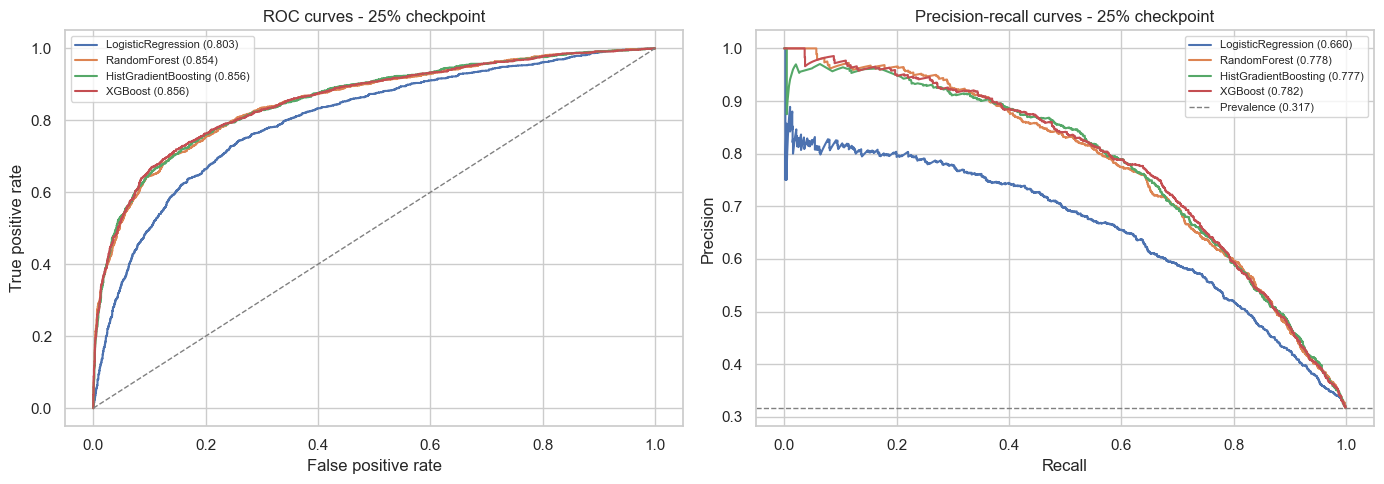

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for model_name, probability in early_probabilities.items():
    fpr, tpr, _ = roc_curve(y_eval, probability)
    axes[0].plot(fpr, tpr, label=f"{model_name} ({roc_auc_score(y_eval, probability):.3f})")
    precision, recall, _ = precision_recall_curve(y_eval, probability)
    axes[1].plot(recall, precision, label=f"{model_name} ({average_precision_score(y_eval, probability):.3f})")

axes[0].plot([0, 1], [0, 1], "--", color="grey", linewidth=1)
axes[0].set(title="ROC curves - 25% checkpoint", xlabel="False positive rate", ylabel="True positive rate")
axes[1].axhline(y_eval.mean(), linestyle="--", color="grey", linewidth=1, label=f"Prevalence ({y_eval.mean():.3f})")
axes[1].set(title="Precision-recall curves - 25% checkpoint", xlabel="Recall", ylabel="Precision")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Interpretation framework

The comparison answers two different questions:

- **Can the published aggregate feature design reach its reported range when later-course evidence is allowed?** See the whole-course reconstruction and ten-fold diagnostic.
- **Does that feature design improve the current early-withdrawal model under the same target, cutoff, and student-grouped partition?** See the fair evaluation table.

Differences between the two experiments should be attributed first to information availability and split design, not to the classifier name. Full-course VLE activity and assessment averages encode persistence that is only observable after an early intervention would need to occur.

In [13]:
best_early = early_results.iloc[0].to_dict()
delta_pr = best_early["pr_auc"] - BASELINE_REFERENCE["pr_auc"]
delta_roc = best_early["roc_auc"] - BASELINE_REFERENCE["roc_auc"]

summary_table = pd.DataFrame([
    {
        "question": "Published whole-course setup",
        "best_model": full_results.iloc[0]["model"],
        "roc_auc": full_results.iloc[0]["roc_auc"],
        "pr_auc": full_results.iloc[0]["pr_auc"],
        "directly_comparable_to_baseline": False,
    },
    {
        "question": "Current 25% grouped baseline",
        "best_model": BASELINE_REFERENCE["model"],
        "roc_auc": BASELINE_REFERENCE["roc_auc"],
        "pr_auc": BASELINE_REFERENCE["pr_auc"],
        "directly_comparable_to_baseline": True,
    },
    {
        "question": "Jha features at 25% with grouped split",
        "best_model": best_early["model"],
        "roc_auc": best_early["roc_auc"],
        "pr_auc": best_early["pr_auc"],
        "directly_comparable_to_baseline": True,
    },
])
display(summary_table.style.format({"roc_auc": "{:.3f}", "pr_auc": "{:.3f}"}))

if delta_pr > 0 or delta_roc > 0:
    conclusion = (
        f"The best literature-feature model changes PR-AUC by {delta_pr:+.3f} and "
        f"ROC-AUC by {delta_roc:+.3f} versus the frozen baseline. "
        "Any adoption decision should also check recall and false negatives."
    )
else:
    conclusion = (
        f"The literature-feature model does not surpass the frozen baseline under the fair setup "
        f"(PR-AUC delta {delta_pr:+.3f}; ROC-AUC delta {delta_roc:+.3f}). "
        "The higher published score is therefore explained by later-course evidence and/or the easier row-level split, "
        "not by a superior model for the same early-warning problem."
    )
print(conclusion)

,question,best_model,roc_auc,pr_auc,directly_comparable_to_baseline
0,Published whole-course setup,HistGradientBoosting,0.922,0.838,False
1,Current 25% grouped baseline,"checkpoint1_EDA_v3: HGB, withdrawal weight 3.0",0.884,0.825,True
2,Jha features at 25% with grouped split,Jha features: XGBoost,0.856,0.782,True


The literature-feature model does not surpass the frozen baseline under the fair setup (PR-AUC delta -0.043; ROC-AUC delta -0.028). The higher published score is therefore explained by later-course evidence and/or the easier row-level split, not by a superior model for the same early-warning problem.


In [14]:
result_record = {
    "target": "Withdrawn vs Pass/Fail/Distinction",
    "checkpoint": "25% of module_presentation_length",
    "full_course_audit": full_audit,
    "early_audit": early_audit,
    "whole_course_results": full_results.to_dict(orient="records"),
    "whole_course_cv_summary": full_cv_summary.to_dict(orient="records"),
    "xgboost_training_only_tuning": xgb_tuning.to_dict(orient="records"),
    "fair_25pct_results": early_results.to_dict(orient="records"),
    "frozen_baseline": BASELINE_REFERENCE,
    "best_fair_delta_pr_auc": float(delta_pr),
    "best_fair_delta_roc_auc": float(delta_roc),
    "conclusion": conclusion,
}
print("LITERATURE_REPLICATION_RESULT_JSON=" + json.dumps(result_record, default=float))

LITERATURE_REPLICATION_RESULT_JSON={"target": "Withdrawn vs Pass/Fail/Distinction", "checkpoint": "25% of module_presentation_length", "full_course_audit": {"window": "whole_course", "rows": 32593, "withdrawn": 10156, "assessment_records_used": 168953, "vle_records_used": 10655280, "raw_predictors": 50}, "early_audit": {"window": "25%", "max_assessment_days_past_cutoff": 0, "max_vle_days_past_cutoff": 0, "rows": 32593, "withdrawn": 10156, "assessment_records_used": 57013, "vle_records_used": 4667957, "raw_predictors": 50}, "whole_course_results": [{"model": "HistGradientBoosting", "accuracy": 0.8302859246533317, "balanced_accuracy": 0.8448287639736334, "precision": 0.6735735735735736, "recall": 0.8834186687672312, "f1": 0.7643550860453229, "roc_auc": 0.9218203511846215, "pr_auc": 0.8382037016875721, "tn": 4523, "fp": 1087, "fn": 296, "tp": 2243}, {"model": "XGBoost", "accuracy": 0.8345809301754816, "balanced_accuracy": 0.8469779812816673, "precision": 0.6817210863594751, "recall": 0.87

## Concise conclusion

This notebook preserved the capstone target: **`Withdrawn = 1`; `Pass`, `Fail`, and `Distinction = 0`**. The Jha-style implementation was evaluated both with whole-course data and under the same leakage-controlled 25% checkpoint used by the current baseline.

| Experiment | Information available | PR-AUC | ROC-AUC | Comparable to baseline? |
|---|---:|---:|---:|---:|
| Current HGB baseline | 25% checkpoint | **0.825** | **0.884** | Yes |
| Jha-style XGBoost | 25% checkpoint | 0.782 | 0.856 | Yes |
| Jha-style HGB | Whole course | **0.838** | **0.922** | No |
| Jha-style HGB, 10-fold CV | Whole course | 0.835 ± 0.013 | 0.921 ± 0.004 | No |

Under the fair 25% comparison, the literature feature set did **not** improve the current baseline: PR-AUC changed by **−0.043** and ROC-AUC by **−0.028**. Its apparently better whole-course result comes from later VLE and assessment evidence that would not be available at the intervention checkpoint, together with a less restrictive row-level split. Therefore, it is not evidence of a better early-warning model.

The approximately 0.97–0.99 results found elsewhere are not directly comparable. [Almazroei et al.](https://www.nature.com/articles/s41598-026-49894-1) report ROC-AUC 0.98834, [Abdo et al.](https://oaji.net/pdf.html?n=2023%2F3603-1760663243.pdf) report 0.973748, and [Azuela et al.](https://www.researchgate.net/publication/399705152_From_Data_to_Action_Narrative_Benchmarking_and_Comparative_Evaluation_of_Explainable_AI-Driven_Supervised_Machine_Learning_Models_for_Academic_Risk_Prediction) report 0.974233, but these studies group **`Fail + Withdrawn`** together against **`Pass + Distinction`** and generally use whole-course evidence. The roughly 0.97 result from [Al-Shabandar et al.](https://researchonline.ljmu.ac.uk/8486/1/New%20update%20paper%20mixture%20model%20PDF%20%20%20last%20Dr%20Abir.pdf) predicts next-assignment non-submission in course BBB rather than the final `Withdrawn` outcome.

**Decision:** retain the existing HGB model as the stronger comparable early-withdrawal baseline. Treat the higher literature numbers as useful demonstrations of how target definition, observation window, leakage risk, and split design can inflate apparent performance—not as replacements for the stated problem.